In [1]:
from langchain_ollama import ChatOllama
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from IPython.display import Image


In [2]:
base_url = "http://localhost:11434"
model = "llama3.2"

llm = ChatOllama(
    base_url=base_url,
    model=model,
    temperature=0.6
)

In [3]:
class BlogState(TypedDict):
    title: str
    outline: str
    blog: str
    score: str

In [4]:
graph = StateGraph(BlogState)

In [5]:
def get_outline(state: BlogState) -> BlogState:
    title = state['title']

    prompt = f"Define the outline to write a blog on the given topic. Topic = {title}"

    outline = llm.invoke(prompt).content

    state['outline'] = outline
    
    return state

In [6]:
def get_blog(state: BlogState) -> BlogState:
    title = state['title']
    outline = state['outline']

    prompt = f"write a blog on {title} and the outline for blog is {outline}"
    blog = llm.invoke(prompt).content

    state['blog'] = blog

    return state


In [7]:
def get_score(state: BlogState) -> BlogState:
    blog = state['blog']
    outline = state['outline']

    prompt = f"Based on this {outline} rate the quality of this {blog} on a scale of 10"
    state['score'] = llm.invoke(prompt).content

    return state

In [8]:
graph.add_node('get_outline', get_outline)
graph.add_node('get_blog', get_blog)
graph.add_node('get_score', get_score)

In [9]:
graph.add_edge(START, 'get_outline')
graph.add_edge('get_outline', 'get_blog')
graph.add_edge('get_blog', 'get_score')
graph.add_edge('get_score', END)

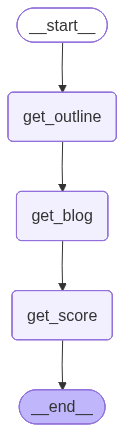

In [15]:
workflow = graph.compile()
workflow

In [11]:
initial_state = {"title":"Moon"}
final_state = workflow.invoke(initial_state)
print(final_state['title'])

Moon


In [12]:
print(final_state['outline'])

Here is a suggested outline for writing a blog on the topic "Moon":

**Title:** Exploring the Wonders of the Moon: A Comprehensive Guide

**I. Introduction**

* Brief overview of the moon's significance in our lives
* Importance of understanding the moon and its effects on Earth
* Thesis statement: The moon is a fascinating celestial body with a rich history, unique features, and significant impact on our planet.

**II. History of the Moon**

* Ancient myths and legends about the moon
* Scientific discoveries about the moon's formation and evolution
* Key milestones in space exploration, including lunar landings

**III. Physical Characteristics of the Moon**

* Geology: composition, craters, mountains, and lava flows
* Atmosphere: lack of atmosphere and its effects on temperature and radiation
* Phases: explanation of the different lunar phases and their causes

**IV. Effects of the Moon on Earth**

* Tides: explanation of how the moon's gravitational pull affects ocean tides
* Stabili

In [13]:
print(final_state['blog'])

Here is a blog post based on the provided outline:

**Exploring the Wonders of the Moon: A Comprehensive Guide**

The moon has been a source of fascination and inspiration for humans throughout our history. From ancient myths and legends to modern-day space exploration, the moon continues to captivate our imagination and spark our curiosity. In this comprehensive guide, we will delve into the world of the moon, exploring its history, physical characteristics, effects on Earth, cultural significance, and more.

**I. Introduction**

The moon is a celestial body that has been an integral part of human experience for thousands of years. Its influence on our lives is multifaceted, ranging from the tides to our personal experiences with the night sky. Understanding the moon's significance in our lives can provide valuable insights into its unique features and importance in our planet's history.

The moon's effects on Earth are profound, from stabilizing our axis to influencing plant growth a

In [14]:
print(final_state['score'])

I'd rate the quality of this blog post as an 8 out of 10.

Here's why:

Strengths:

1. Comprehensive outline: The blogger has followed the provided outline closely, covering all the required topics in detail.
2. Clear structure: The post is well-organized and easy to follow, with each section building upon the previous one.
3. Engaging writing style: The blog post is written in a clear and concise manner, making it enjoyable to read.
4. Use of examples and anecdotes: The blogger uses relevant examples and anecdotes to illustrate complex concepts, making the content more accessible.

Weaknesses:

1. Lack of depth in some sections: While the blogger covers all the required topics, they might not delve as deeply into each section as a reader would like.
2. Limited use of visual aids: The blog post could benefit from more images, diagrams, or infographics to break up the text and illustrate complex concepts.
3. Some sentences feel repetitive: A few sentences, such as those explaining the m